# Assignments - Digital options

Create a new folder under <b>QuantCourseBP\homeworks</b> and copy over the content of this lecture's solution folder to start with.

1. Get familiar with digital options and implement EuropeanDigitalContract and EuropeanDigitalAnalyticPricer (fair value and greeks) in the library. Implement unit test for fair value using pytest. **(12 points)**
2. Get familiar with bull spread options and by utilizing EuropeanDigitalAnalyticPricer and EuropeanAnalyticPricer, create a figure to visualize that a digital call option can be thought of as a limit of bull spread call options. **(8 points)**

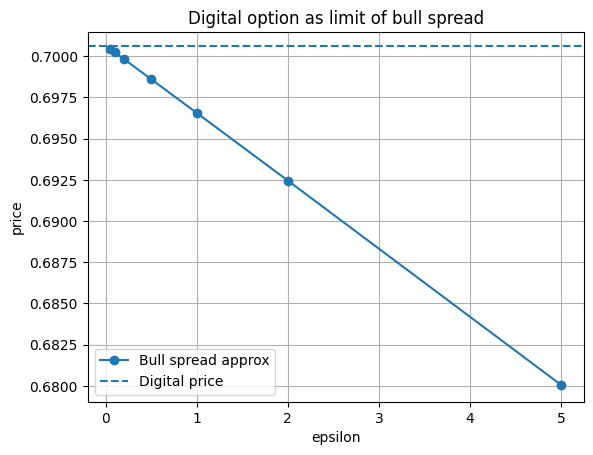

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from typing import Dict, List, Union

import sys
from pathlib import Path
current = Path(Path().resolve())
sys.path.append(str(current))
sys.path.append(str(current.parents[2]))

from enum import *
from pricer import *

def bull_spread_price(call_pricer, K: float, eps: float) -> float:
    c1 = call_pricer.calc_fair_value()
    
    # ide "hack": új contract K+eps-szel
    call_pricer.contract.strike = K + eps
    c2 = call_pricer.calc_fair_value()
    
    # visszaállítás (FONTOS!)
    call_pricer.contract.strike = K

    return (c1 - c2) / eps

class ModelAdapter:
    def __init__(self, stock):
        self.spot = MarketData.get_spot()[stock]
        self.vol = MarketData.get_vol()[stock]
        self.risk_free_rate = MarketData.get_risk_free_rate()
    def calc_df(self, t: float) -> float:
        return np.exp(-self.risk_free_rate * t)

# alap paraméterek
S0 = 100
K = 100
r = 0.05
sigma = 0.2
T = 1.0


stock = Stock.BLUECHIP_BANK

model = ModelAdapter(stock)
params = Params()


S0 = MarketData.get_spot()[stock]
sigma = MarketData.get_vol()[stock]
r = MarketData.get_risk_free_rate()

# vanilla call contract
call_contract = EuropeanContract(
    underlying=None,
    derivative_type=PutCallFwd.CALL,
    long_short=LongShort.LONG,
    strike=K,
    expiry=T
)

call_pricer = EuropeanAnalyticPricer(call_contract, model, params)

# digital contract + pricer
digital_contract = EuropeanDigitalContract(
    underlying=None,
    derivative_type=PutCallFwd.CALL,
    long_short=LongShort.LONG,
    strike=K,
    expiry=T
)

digital_pricer = EuropeanDigitalAnalyticPricer(digital_contract, model, params)
digital_price = digital_pricer.calc_fair_value()

# epsilon grid
eps_values = np.array([5, 2, 1, 0.5, 0.2, 0.1, 0.05])
approximations = []

for eps in eps_values:
    approx = bull_spread_price(call_pricer, K, eps)
    approximations.append(approx)

# plot
plt.plot(eps_values, approximations, marker='o', label="Bull spread approx")
plt.axhline(digital_price, linestyle='--', label="Digital price")

plt.xlabel("epsilon")
plt.ylabel("price")
plt.title("Digital option as limit of bull spread")
plt.legend()
plt.grid()
plt.show()